In [11]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA

from simplexity.generative_processes.builder import build_hidden_markov_model
from simplexity.generative_processes.generator import generate_data_batch_with_full_history
from simplexity.utils.pytorch_utils import jax_to_torch
from src.hmm.hmm import belief_to_barycentric

from tqdm.auto import tqdm
import transformer_lens as tl

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

## Parameters

In [13]:
SEQ_LENGTH = 2000
HMM_CONCEPTS = ['A', 'B', 'C']
N_SEQUENCES = 10

## Build HMM & Generate Sequences

In [14]:
hmm = build_hidden_markov_model(
    "mess3",
    process_params={"x": 0.05, "a": 0.85},
    device=None,
)

print(f"Vocab size (symbols): {hmm.vocab_size}")
print(f"Num hidden states: {hmm.num_states}")
print(f"Initial state (belief): {jax_to_torch(hmm.initial_state).tolist()}")

emission_rows = []
for i in range(hmm.num_states):
    pure_state = jnp.zeros(hmm.num_states).at[i].set(1.0)
    obs_probs = hmm.observation_probability_distribution(pure_state)
    emission_rows.append(jax_to_torch(obs_probs))
emission_matrix = torch.stack(emission_rows)

print(f"\nEmission matrix (rows=states, cols=tokens A,B,C):")
print(emission_matrix)
print(f"\nRow sums (should be 1): {emission_matrix.sum(dim=1)}")

Vocab size (symbols): 3
Num hidden states: 3
Initial state (belief): [0.33333343267440796, 0.3333333134651184, 0.33333325386047363]

Emission matrix (rows=states, cols=tokens A,B,C):
tensor([[0.7725, 0.1137, 0.1137],
        [0.1137, 0.7725, 0.1137],
        [0.1138, 0.1138, 0.7725]])

Row sums (should be 1): tensor([1., 1., 1.])


In [15]:
sequence_len = SEQ_LENGTH + 1
key = jax.random.PRNGKey(42)
gen_states = jnp.tile(hmm.initial_state, (N_SEQUENCES, 1))

next_states, belief_states_jax, prefix_probs, inputs_jax, labels_jax = generate_data_batch_with_full_history(
    gen_states, hmm, N_SEQUENCES, sequence_len, key
)

tokens = jax_to_torch(inputs_jax)
tokens_y = jax_to_torch(labels_jax)
belief_states_all = jax_to_torch(belief_states_jax).cpu().numpy()
obs_probs_all_jax = jnp.einsum('bns,vst->bnv', belief_states_jax, hmm.transition_matrices)
obs_probs_all = jax_to_torch(obs_probs_all_jax)

walk_concepts = [[HMM_CONCEPTS[int(t)] for t in seq] for seq in tokens]

print(f"Num sequences: {tokens.shape[0]}, Sequence length: {tokens.shape[1]}")
print(f"First 20 tokens (seq 0): {walk_concepts[0][:20]}")
print(f"Belief states shape: {belief_states_all.shape}")
print(f"Belief states sum to 1? {np.allclose(belief_states_all.sum(axis=-1), 1)}")

Num sequences: 10, Sequence length: 2000
First 20 tokens (seq 0): ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'B', 'B', 'B', 'A', 'C', 'C', 'A', 'C', 'C', 'C', 'A', 'B']
Belief states shape: (10, 2001, 3)
Belief states sum to 1? True


## Load Model (TransformerLens)

In [16]:
MODEL_NAME = "meta-llama/Llama-3.2-3B"
N_DEVICES = min(torch.cuda.device_count(), 4)

print(f"Loading {MODEL_NAME} across {N_DEVICES} GPUs...")
model = tl.HookedTransformer.from_pretrained(
    MODEL_NAME,
    device="cuda",
    n_devices=N_DEVICES,
    torch_dtype=torch.float16,
    n_ctx=4098
)
model.eval()
print(f"Model loaded. {model.cfg.n_layers} layers, d_model={model.cfg.d_model}")
print(f"Context window: {model.cfg.n_ctx}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading meta-llama/Llama-3.2-3B across 4 GPUs...


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.34it/s]


Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer
Model loaded. 28 layers, d_model=3072
Context window: 4098


In [17]:
def get_concept_token_ids(model, concepts):
    """Get the token IDs for each concept (with space prefix)."""
    concept_to_id = {}
    for concept in concepts:
        spaced = f" {concept}"
        ids = model.to_tokens(spaced, prepend_bos=False)[0]
        concept_to_id[concept] = ids[-1].item()
    return concept_to_id

## Forward Pass (with activation caching)

In [18]:
LAYERS_TO_ANALYZE = list(range(model.cfg.n_layers))
print(f"Will analyze layers: {LAYERS_TO_ANALYZE}")

letter_set = set(HMM_CONCEPTS)

all_activations = {layer: [] for layer in LAYERS_TO_ANALYZE}
all_logits = []
all_beliefs = []
all_positions = []

for seq_idx in tqdm(range(N_SEQUENCES), desc="Processing sequences"):
    seq_concepts = walk_concepts[seq_idx]
    beliefs = belief_states_all[seq_idx]

    prompt = seq_concepts[0] + " " + " ".join(seq_concepts[1:])
    input_ids = model.to_tokens(prompt, prepend_bos=True).to(model.embed.W_E.device)
    str_tokens = model.to_str_tokens(prompt, prepend_bos=True)

    positions = [i for i, tok in enumerate(str_tokens) if tok.strip() in letter_set]

    n_use = min(len(positions), len(seq_concepts))
    if len(positions) != len(seq_concepts):
        print(f"Warning seq {seq_idx}: expected {len(seq_concepts)} letter positions, got {len(positions)}")
    positions = positions[:n_use]

    with torch.no_grad():
        _, cache = model.run_with_cache(
            input_ids,
            names_filter=[f"blocks.{l}.hook_resid_post" for l in LAYERS_TO_ANALYZE],
            return_type=None,
        )

        for layer in LAYERS_TO_ANALYZE:
            hook_name = f"blocks.{layer}.hook_resid_post"
            layer_acts = cache[hook_name][0]
            letter_acts = layer_acts[positions].cpu().float().numpy()
            all_activations[layer].append(letter_acts)

        last_resid = cache[f"blocks.{LAYERS_TO_ANALYZE[-1]}.hook_resid_post"]
        last_resid = last_resid.to(model.unembed.W_U.device)
        logits = model.unembed(model.ln_final(last_resid))
        seq_logits = logits[0, positions].cpu().float().detach().numpy()
        all_logits.append(seq_logits)
        del logits, last_resid, cache

    all_beliefs.append(beliefs[1:n_use + 1])
    all_positions.append(np.arange(n_use))
    torch.cuda.empty_cache()

for layer in LAYERS_TO_ANALYZE:
    all_activations[layer] = np.concatenate(all_activations[layer], axis=0)
all_logits_flat = np.concatenate(all_logits, axis=0)
all_beliefs_flat = np.concatenate(all_beliefs, axis=0)
all_positions_flat = np.concatenate(all_positions, axis=0)

print(f"\nTotal datapoints: {len(all_beliefs_flat)}")
print(f"Logits shape: {all_logits_flat.shape}")
print(f"Activations shape per layer: {all_activations[LAYERS_TO_ANALYZE[0]].shape}")
print(f"Beliefs shape: {all_beliefs_flat.shape}")
print(f"Position range: {all_positions_flat.min()} to {all_positions_flat.max()}")

Will analyze layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]


Processing sequences: 100%|██████████| 10/10 [00:46<00:00,  4.62s/it]



Total datapoints: 20000
Logits shape: (20000, 128256)
Activations shape per layer: (20000, 3072)
Beliefs shape: (20000, 3)
Position range: 0 to 1999


## Concept Logits & KL Divergence

In [19]:
concept_to_id = get_concept_token_ids(model, HMM_CONCEPTS)
concept_ids = [concept_to_id[c] for c in HMM_CONCEPTS]
print(f"Concept token IDs (ordered): {dict(zip(HMM_CONCEPTS, concept_ids))}")

concept_logits = all_logits_flat[:, concept_ids]
llm_probs = F.softmax(torch.tensor(concept_logits), dim=-1).numpy()

print(f"Concept logits shape: {concept_logits.shape}")
print(f"LLM probs shape: {llm_probs.shape}")

Concept token IDs (ordered): {'A': 362, 'B': 426, 'C': 356}
Concept logits shape: (20000, 3)
LLM probs shape: (20000, 3)


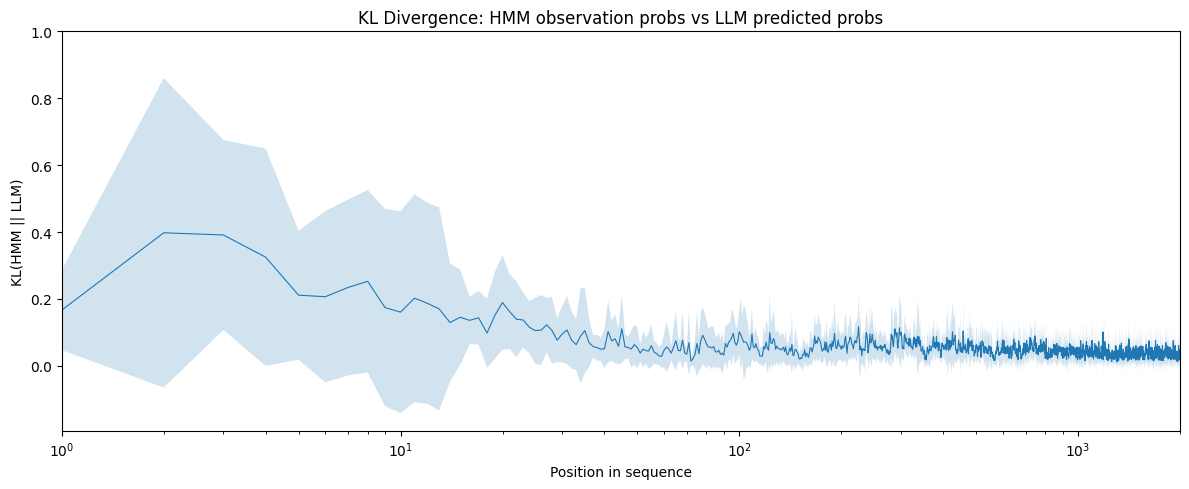

Mean KL over all positions: 0.0465
KL at position 1: 0.1665
KL at position 10: 0.1604
KL at position 100: 0.1017
KL at position 1000: 0.0356
KL at position 1999: 0.0276


In [29]:
llm_probs_3d = llm_probs.reshape(N_SEQUENCES, SEQ_LENGTH, len(HMM_CONCEPTS))
hmm_probs = obs_probs_all[:, 1:, :].cpu().numpy()

eps = 1e-10
p = np.clip(hmm_probs, eps, 1.0)
q = np.clip(llm_probs_3d, eps, 1.0)

kl_per_pos_seq = np.sum(p * np.log(p / q), axis=-1)
kl_mean = kl_per_pos_seq.mean(axis=0)
kl_std = kl_per_pos_seq.std(axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
positions_arr = np.arange(SEQ_LENGTH)
ax.plot(positions_arr, kl_mean, linewidth=0.8)
ax.fill_between(positions_arr, kl_mean - kl_std, kl_mean + kl_std, alpha=0.2)
ax.set_xlabel('Position in sequence')
ax.set_ylabel('KL(HMM || LLM)')
ax.set_title('KL Divergence: HMM observation probs vs LLM predicted probs')
ax.set_xscale('log')
ax.set_xlim(1, SEQ_LENGTH)
ax.set_ylim(None, 1)
plt.tight_layout()
plt.show()

print(f"Mean KL over all positions: {kl_mean.mean():.4f}")
for i in [1, 10, 100, 1000, 1999]:
    print(f"KL at position {i}: {kl_mean[i]:.4f}")

## Linear Probe: Belief State Regression

In [21]:
regression_results = {}

for layer in LAYERS_TO_ANALYZE:
    acts = all_activations[layer]
    beliefs = all_beliefs_flat

    X_train, X_test, y_train, y_test = train_test_split(
        acts, beliefs, test_size=0.2, random_state=42
    )

    reg = LinearRegression()
    reg.fit(X_train, y_train)

    y_pred_train = reg.predict(X_train)
    y_pred_test = reg.predict(X_test)

    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)

    projected = reg.predict(acts)

    regression_results[layer] = {
        'model': reg,
        'mse_train': mse_train,
        'mse_test': mse_test,
        'projected': projected,
    }

    print(f"Layer {layer:2d}: MSE train={mse_train:.6f}, MSE test={mse_test:.6f}")

Layer  0: MSE train=0.000986, MSE test=0.000989
Layer  1: MSE train=0.000203, MSE test=0.000211
Layer  2: MSE train=0.000116, MSE test=0.000149
Layer  3: MSE train=0.000097, MSE test=0.000158
Layer  4: MSE train=0.000098, MSE test=0.000129
Layer  5: MSE train=0.000110, MSE test=0.000209
Layer  6: MSE train=0.000150, MSE test=0.000266
Layer  7: MSE train=0.000187, MSE test=0.000330
Layer  8: MSE train=0.000272, MSE test=0.000492
Layer  9: MSE train=0.000388, MSE test=0.000737
Layer 10: MSE train=0.000499, MSE test=0.000917
Layer 11: MSE train=0.000563, MSE test=0.000973
Layer 12: MSE train=0.000615, MSE test=0.001056
Layer 13: MSE train=0.000612, MSE test=0.001089
Layer 14: MSE train=0.000616, MSE test=0.001080
Layer 15: MSE train=0.000619, MSE test=0.001028
Layer 16: MSE train=0.000625, MSE test=0.000987
Layer 17: MSE train=0.000640, MSE test=0.001029
Layer 18: MSE train=0.000636, MSE test=0.001000
Layer 19: MSE train=0.000658, MSE test=0.001008
Layer 20: MSE train=0.000682, MSE test=0

In [22]:
regression_results_main = regression_results

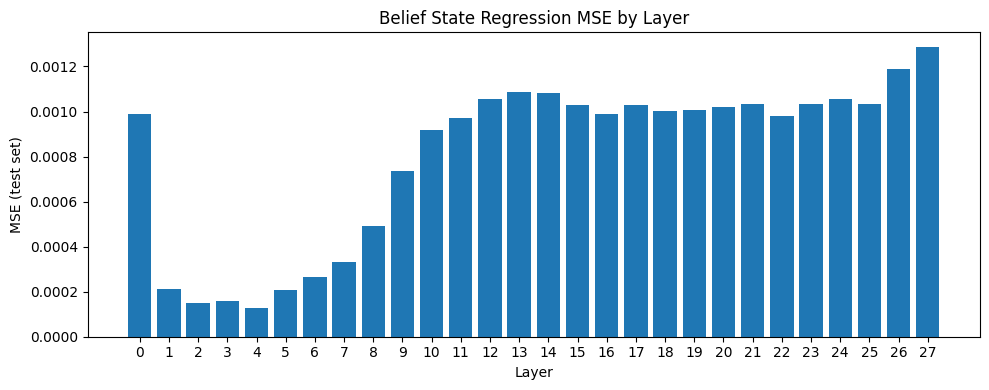

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

layers = sorted(regression_results.keys())
mse_values = [regression_results[l]['mse_test'] for l in layers]

ax.bar(range(len(layers)), mse_values, tick_label=[str(l) for l in layers])
ax.set_xlabel('Layer')
ax.set_ylabel('MSE (test set)')
ax.set_title('Belief State Regression MSE by Layer')
plt.tight_layout()
plt.show()

## Logit Lens & Tuned Logit Lens

Apply the **logit lens** and **tuned logit lens** to each layer's residual stream and compute KL divergence against HMM observation probabilities.

- **Logit lens**: directly apply `ln_final` + `unembed` to each intermediate hidden state (no training).
- **Tuned logit lens**: learn a per-layer affine translator `T_l: h_l → h̃` before applying `ln_final` + `unembed`. The translator is trained to match the model's full output distribution over concept tokens.

In [24]:
# Align HMM observation probabilities with the flat activations.
#
# obs_probs_all[b, t] = P(next token | belief at step t) for the HMM
# The activation at concept position t predicts the (t+1)-th concept token.
# Therefore we align with obs_probs_all[:, 1:SEQ_LENGTH+1, :].
#
# Shapes:
#   obs_probs_all : (N_SEQUENCES, SEQ_LENGTH+1, 3)  -- HMM vocab size is 3
#   hmm_probs_flat: (N_SEQUENCES * SEQ_LENGTH, 3)   -- aligned with all_activations

hmm_probs_flat = obs_probs_all[:, 1:SEQ_LENGTH + 1, :].cpu().numpy().reshape(-1, 3)

print(f"HMM probs shape : {hmm_probs_flat.shape}")
print(f"Row-sum check   : min={hmm_probs_flat.sum(1).min():.6f}, max={hmm_probs_flat.sum(1).max():.6f}")
print(f"Concept IDs (A,B,C): {concept_ids}")

HMM probs shape : (20000, 3)
Row-sum check   : min=1.000000, max=1.000000
Concept IDs (A,B,C): [362, 426, 356]


In [25]:
import torch.nn as nn

# ─── Logit Lens (no training) ───────────────────────────────────────────────
# For efficiency we only project onto the 3 concept-token directions instead
# of materialising the full 128256-token logit vector.
# NOTE: softmax(concept_logits) gives the *conditional* probability over
# {A, B, C}, consistent with how cell-13 treated the final-layer output.

_unembed_device = model.unembed.W_U.device

# Pre-extract concept columns once (d_model × 3)
W_concept = model.unembed.W_U[:, concept_ids].detach()   # (3072, 3)
b_concept = model.unembed.b_U[concept_ids].detach()       # (3,)

_EPS = 1e-10
_BATCH = 1024

logit_lens_probs   = {}   # layer → (N, 3) concept probabilities
logit_lens_kl_mean = {}   # layer → mean KL
logit_lens_kl_all  = {}   # layer → (N,)  per-sample KL

with torch.no_grad():
    for layer in tqdm(LAYERS_TO_ANALYZE, desc="Logit lens"):
        acts = torch.tensor(all_activations[layer], dtype=torch.float32)
        n    = acts.shape[0]
        probs_list = []

        for start in range(0, n, _BATCH):
            batch = acts[start : start + _BATCH].to(_unembed_device)
            normed        = model.ln_final(batch)            # (B, d_model)
            concept_logit = normed @ W_concept + b_concept   # (B, 3)
            probs_list.append(F.softmax(concept_logit, dim=-1).cpu().numpy())

        probs = np.concatenate(probs_list, axis=0)          # (N, 3)
        logit_lens_probs[layer] = probs

        p   = np.clip(hmm_probs_flat, _EPS, 1.0)
        q   = np.clip(probs / probs.sum(1, keepdims=True), _EPS, 1.0)
        kl  = np.sum(p * np.log(p / q), axis=-1)           # (N,)

        logit_lens_kl_mean[layer] = float(kl.mean())
        logit_lens_kl_all[layer]  = kl

    torch.cuda.empty_cache()

print("\nLogit lens  KL(HMM ‖ lens) per layer:")
for l in LAYERS_TO_ANALYZE:
    print(f"  Layer {l:2d}: {logit_lens_kl_mean[l]:.4f}")

Logit lens: 100%|██████████| 28/28 [00:02<00:00, 10.78it/s]


Logit lens  KL(HMM ‖ lens) per layer:
  Layer  0: inf
  Layer  1: inf
  Layer  2: 1.5265
  Layer  3: 0.8990
  Layer  4: 0.9525
  Layer  5: 0.6756
  Layer  6: 0.5462
  Layer  7: 0.6023
  Layer  8: 0.5753
  Layer  9: 0.7535
  Layer 10: 0.7811
  Layer 11: 0.8332
  Layer 12: 0.5140
  Layer 13: 0.2977
  Layer 14: 0.1573
  Layer 15: 0.1469
  Layer 16: 0.2156
  Layer 17: 0.1424
  Layer 18: 0.1361
  Layer 19: 0.1168
  Layer 20: 0.6694
  Layer 21: 0.6324
  Layer 22: 0.2576
  Layer 23: 0.1453
  Layer 24: 0.1629
  Layer 25: 0.6094
  Layer 26: 0.5519
  Layer 27: 0.0464


In [28]:
# ─── Tuned Logit Lens ───────────────────────────────────────────────────────
# Per-layer affine translator  T_l : R^{d_model} → R^{d_model}
# Initialized as the identity so training starts from the logit-lens baseline.
# Trained to minimise KL( model_concept_probs ‖ tuned_lens_concept_probs ).
#
# Training is done on stored activations (no second forward pass through LLaMA).
# Only concept-token logits are used for the loss, keeping training fast.

class TunedLensTranslator(nn.Module):
    """Affine map h_l → h̃, initialized as identity."""

    def __init__(self, d_model: int):
        super().__init__()
        self.linear = nn.Linear(d_model, d_model, bias=True)
        nn.init.eye_(self.linear.weight)
        nn.init.zeros_(self.linear.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(x)


def train_tuned_lens(
    all_activations,
    model,
    concept_ids,
    layers,
    target_concept_logits_flat,   # (N, 3) – final model logits for concept tokens
    n_epochs: int = 50,
    lr: float = 1e-3,
    batch_size: int = 512,
):
    """
    Train one TunedLensTranslator per layer.

    Each translator is optimised so that:
        softmax( unembed(ln_final(T_l(h_l)))[concept_ids] )
    matches the model's concept-token distribution as closely as possible
    (KL divergence minimised).
    """
    device   = model.unembed.W_U.device
    d_model  = model.cfg.d_model

    # Fixed concept projection matrices (never updated during training)
    W_c = model.unembed.W_U[:, concept_ids].detach()   # (d_model, 3)
    b_c = model.unembed.b_U[concept_ids].detach()       # (3,)

    # Target probabilities from the full model (fixed)
    target_probs = F.softmax(
        torch.tensor(target_concept_logits_flat, dtype=torch.float32), dim=-1
    )  # (N, 3)

    translators  = {}
    all_losses   = {}

    for layer in tqdm(layers, desc="Training tuned lens"):
        acts = torch.tensor(all_activations[layer], dtype=torch.float32)
        n    = acts.shape[0]

        translator = TunedLensTranslator(d_model).to(device)
        optimizer  = torch.optim.Adam(translator.parameters(), lr=lr)
        scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=n_epochs
        )

        epoch_losses = []
        for epoch in range(n_epochs):
            perm       = torch.randperm(n)
            epoch_loss = 0.0
            n_batches  = 0

            for start in range(0, n, batch_size):
                idx           = perm[start : start + batch_size]
                acts_batch    = acts[idx].to(device)
                target_batch  = target_probs[idx].to(device)   # (B, 3)

                optimizer.zero_grad()

                h             = translator(acts_batch)          # (B, d_model)
                normed        = model.ln_final(h)               # (B, d_model)
                concept_logit = normed @ W_c + b_c              # (B, 3)
                log_probs     = F.log_softmax(concept_logit, dim=-1)

                # KL( model_probs ‖ lens_probs )
                loss = F.kl_div(log_probs, target_batch, reduction="batchmean")
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()
                n_batches  += 1

            scheduler.step()
            epoch_losses.append(epoch_loss / n_batches)

        translators[layer] = translator.cpu().eval()
        for p in translators[layer].parameters():
            p.requires_grad = False
        all_losses[layer]  = epoch_losses
        torch.cuda.empty_cache()

    return translators, all_losses


# Target: the final model's concept logits (cell-13 already computed these)
_model_concept_logits = all_logits_flat[:, concept_ids]   # (N, 3)
print(f"Model concept logits shape: {_model_concept_logits.shape}")

tuned_lens_translators, training_losses = train_tuned_lens(
    all_activations,
    model,
    concept_ids,
    LAYERS_TO_ANALYZE,
    _model_concept_logits,
    n_epochs=50,
    lr=1e-3,
    batch_size=512,
)

Model concept logits shape: (20000, 3)


Training tuned lens: 100%|██████████| 28/28 [10:07<00:00, 21.69s/it]


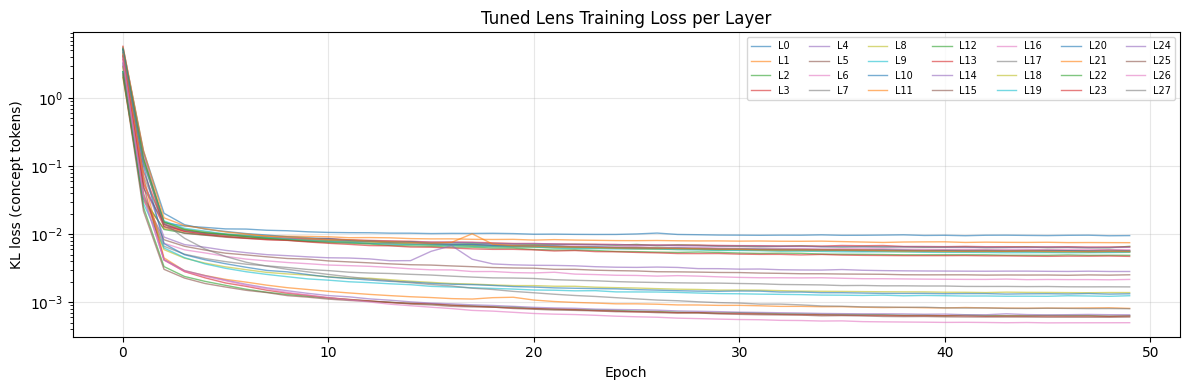

In [30]:
# ─── Training loss curves ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

for layer in LAYERS_TO_ANALYZE:
    ax.plot(training_losses[layer], alpha=0.6, linewidth=1, label=f'L{layer}')

ax.set_xlabel("Epoch")
ax.set_ylabel("KL loss (concept tokens)")
ax.set_title("Tuned Lens Training Loss per Layer")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
# legend outside to avoid clutter
ax.legend(ncol=7, fontsize=7, loc="upper right")
plt.tight_layout()
plt.show()

In [31]:
# ─── Evaluate tuned lens: concept probs + KL(HMM ‖ tuned_lens) ─────────────

tuned_lens_probs   = {}
tuned_lens_kl_mean = {}
tuned_lens_kl_all  = {}

with torch.no_grad():
    for layer in tqdm(LAYERS_TO_ANALYZE, desc="Evaluating tuned lens"):
        translator = tuned_lens_translators[layer].to(_unembed_device)
        acts       = torch.tensor(all_activations[layer], dtype=torch.float32)
        n          = acts.shape[0]
        probs_list = []

        for start in range(0, n, _BATCH):
            batch         = acts[start : start + _BATCH].to(_unembed_device)
            h             = translator(batch)
            normed        = model.ln_final(h)
            concept_logit = normed @ W_concept + b_concept
            probs_list.append(F.softmax(concept_logit, dim=-1).cpu().numpy())

        probs = np.concatenate(probs_list, axis=0)      # (N, 3)
        tuned_lens_probs[layer] = probs

        p  = np.clip(hmm_probs_flat, _EPS, 1.0)
        q  = np.clip(probs / probs.sum(1, keepdims=True), _EPS, 1.0)
        kl = np.sum(p * np.log(p / q), axis=-1)

        tuned_lens_kl_mean[layer] = float(kl.mean())
        tuned_lens_kl_all[layer]  = kl

        translator.cpu()

torch.cuda.empty_cache()

print("\nTuned lens  KL(HMM ‖ tuned lens) per layer:")
for l in LAYERS_TO_ANALYZE:
    delta = tuned_lens_kl_mean[l] - logit_lens_kl_mean[l]
    sign  = "↓" if delta < 0 else "↑"
    print(f"  Layer {l:2d}: {tuned_lens_kl_mean[l]:.4f}  "
          f"(logit lens: {logit_lens_kl_mean[l]:.4f}, Δ={delta:+.4f} {sign})")

Evaluating tuned lens: 100%|██████████| 28/28 [00:10<00:00,  2.69it/s]


Tuned lens  KL(HMM ‖ tuned lens) per layer:
  Layer  0: 0.0354  (logit lens: inf, Δ=-inf ↓)
  Layer  1: 0.0382  (logit lens: inf, Δ=-inf ↓)
  Layer  2: 0.0390  (logit lens: 1.5265, Δ=-1.4875 ↓)
  Layer  3: 0.0387  (logit lens: 0.8990, Δ=-0.8603 ↓)
  Layer  4: 0.0388  (logit lens: 0.9525, Δ=-0.9137 ↓)
  Layer  5: 0.0395  (logit lens: 0.6756, Δ=-0.6360 ↓)
  Layer  6: 0.0395  (logit lens: 0.5462, Δ=-0.5067 ↓)
  Layer  7: 0.0399  (logit lens: 0.6023, Δ=-0.5624 ↓)
  Layer  8: 0.0405  (logit lens: 0.5753, Δ=-0.5348 ↓)
  Layer  9: 0.0408  (logit lens: 0.7535, Δ=-0.7127 ↓)
  Layer 10: 0.0407  (logit lens: 0.7811, Δ=-0.7404 ↓)
  Layer 11: 0.0407  (logit lens: 0.8332, Δ=-0.7925 ↓)
  Layer 12: 0.0412  (logit lens: 0.5140, Δ=-0.4728 ↓)
  Layer 13: 0.0412  (logit lens: 0.2977, Δ=-0.2566 ↓)
  Layer 14: 0.0429  (logit lens: 0.1573, Δ=-0.1144 ↓)
  Layer 15: 0.0433  (logit lens: 0.1469, Δ=-0.1036 ↓)
  Layer 16: 0.0436  (logit lens: 0.2156, Δ=-0.1720 ↓)
  Layer 17: 0.0441  (logit lens: 0.1424, Δ=-0.098

Text(0.5, 1.0, 'KL Divergence Logit lens')

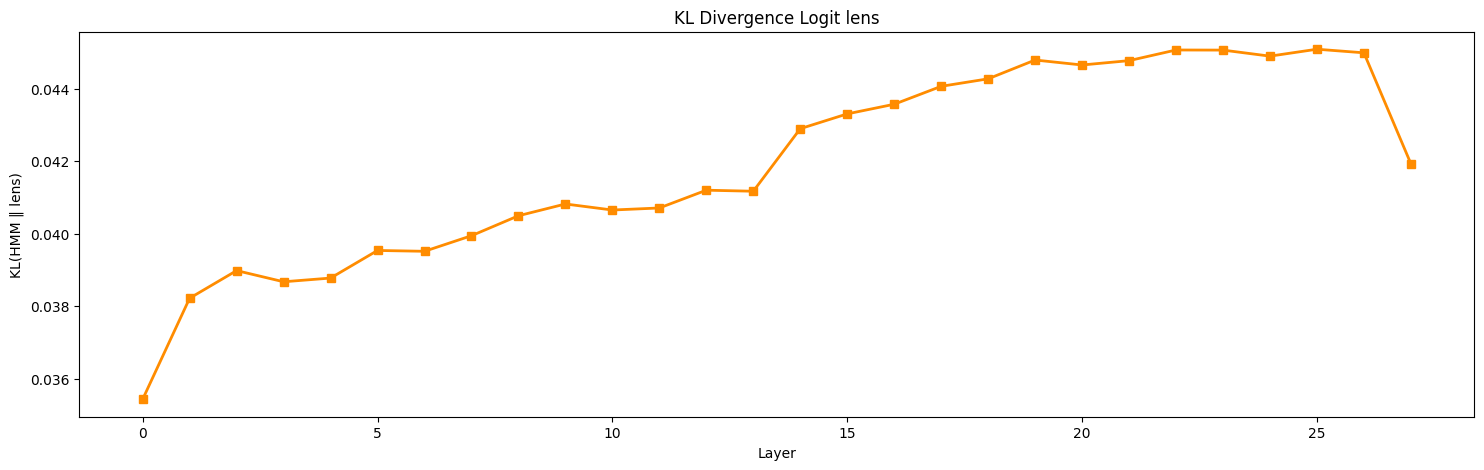

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(18, 5))

kl_logit  = [logit_lens_kl_mean[l]  for l in layers_sorted]
kl_tuned  = [tuned_lens_kl_mean[l]  for l in layers_sorted]

# ── Panel 1: KL divergence by layer ──────────────────────────────────────
ax.plot(layers_sorted, kl_tuned, "s-", color="darkorange", linewidth=2,
        label="Tuned Logit Lens")
ax.set_xlabel("Layer")
ax.set_ylabel("KL(HMM ‖ lens)")
ax.set_title("KL Divergence Tuned lens")

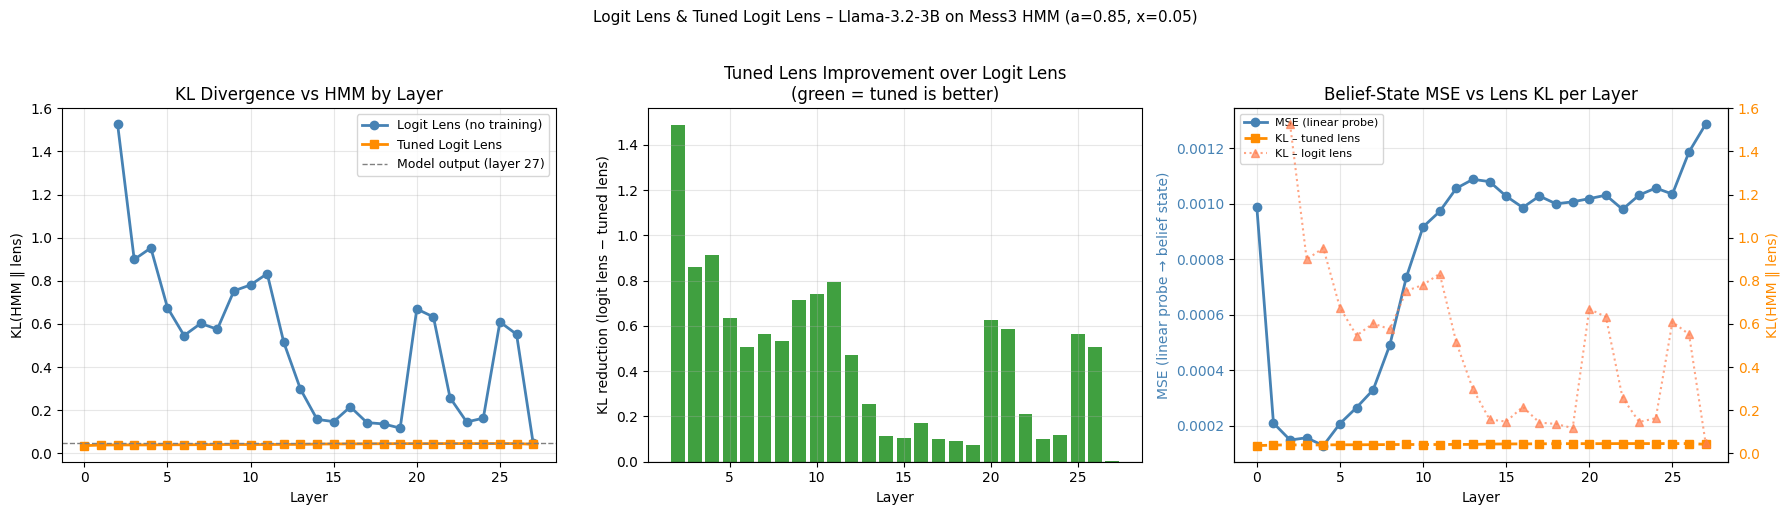


Layer       MSE    KL logit    KL tuned      Δ KL
--------------------------------------------------
   0   0.00099   inf    0.03543   -inf
   1   0.00021   inf    0.03822   -inf
   2   0.00015   1.52648    0.03898   -1.48750
   3   0.00016   0.89901    0.03867   -0.86034
   4   0.00013   0.95250    0.03877   -0.91372
   5   0.00021   0.67558    0.03954   -0.63604
   6   0.00027   0.54619    0.03951   -0.50668
   7   0.00033   0.60234    0.03994   -0.56239
   8   0.00049   0.57532    0.04049   -0.53482
   9   0.00074   0.75349    0.04082   -0.71267
  10   0.00092   0.78107    0.04065   -0.74041
  11   0.00097   0.83322    0.04071   -0.79251
  12   0.00106   0.51399    0.04120   -0.47279
  13   0.00109   0.29774    0.04117   -0.25657
  14   0.00108   0.15728    0.04290   -0.11438
  15   0.00103   0.14689    0.04331   -0.10359
  16   0.00099   0.21558    0.04357   -0.17201
  17   0.00103   0.14239    0.04407   -0.09832
  18   0.00100   0.13612    0.04428   -0.09185
  19   0.00101   0.11

In [36]:
# ─── Comparison plots ───────────────────────────────────────────────────────

layers_sorted = sorted(LAYERS_TO_ANALYZE)

kl_logit  = [logit_lens_kl_mean[l]  for l in layers_sorted]
kl_tuned  = [tuned_lens_kl_mean[l]  for l in layers_sorted]
mse_main  = [regression_results_main[l]['mse_test'] for l in layers_sorted]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel 1: KL divergence by layer ──────────────────────────────────────
ax = axes[0]
ax.plot(layers_sorted, kl_logit, "o-", color="steelblue",  linewidth=2,
        label="Logit Lens (no training)")
ax.plot(layers_sorted, kl_tuned, "s-", color="darkorange", linewidth=2,
        label="Tuned Logit Lens")
# Final model baseline (layer-27 logit lens = model output, same as cell-13)
ax.axhline(logit_lens_kl_mean[layers_sorted[-1]], color="grey",
           linestyle="--", linewidth=1, label="Model output (layer 27)")
ax.set_xlabel("Layer")
ax.set_ylabel("KL(HMM ‖ lens)")
ax.set_title("KL Divergence vs HMM by Layer")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Panel 2: Tuned-lens improvement (KL reduction) ───────────────────────
ax = axes[1]
kl_reduction = [kl_logit[i] - kl_tuned[i] for i in range(len(layers_sorted))]
colors = ["green" if r > 0 else "red" for r in kl_reduction]
ax.bar(layers_sorted, kl_reduction, color=colors, alpha=0.75)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Layer")
ax.set_ylabel("KL reduction (logit lens − tuned lens)")
ax.set_title("Tuned Lens Improvement over Logit Lens\n(green = tuned is better)")
ax.grid(True, alpha=0.3)

# ── Panel 3: MSE (linear probe) vs KL (tuned lens) – dual y-axis ─────────
ax1 = axes[2]
ax2 = ax1.twinx()

color_mse = "steelblue"
color_kl  = "darkorange"

ax1.plot(layers_sorted, mse_main, "o-", color=color_mse, linewidth=2,
         label="MSE (linear probe)")
ax2.plot(layers_sorted, kl_tuned, "s--", color=color_kl, linewidth=2,
         label="KL – tuned lens")
ax2.plot(layers_sorted, kl_logit, "^:", color="coral",   linewidth=1.5,
         label="KL – logit lens", alpha=0.7)
# ax.set_yscale('log')

ax1.set_xlabel("Layer")
ax1.set_ylabel("MSE (linear probe → belief state)", color=color_mse)
ax2.set_ylabel("KL(HMM ‖ lens)",                    color=color_kl)
ax1.tick_params(axis="y", labelcolor=color_mse)
ax2.tick_params(axis="y", labelcolor=color_kl)
ax1.set_title("Belief-State MSE vs Lens KL per Layer")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper left")
ax1.grid(True, alpha=0.3)


plt.suptitle(
    "Logit Lens & Tuned Logit Lens – Llama-3.2-3B on Mess3 HMM (a=0.85, x=0.05)",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
print(f"\n{'Layer':>5}  {'MSE':>8}  {'KL logit':>10}  {'KL tuned':>10}  {'Δ KL':>8}")
print("-" * 50)
for i, l in enumerate(layers_sorted):
    print(f"  {l:2d}   {mse_main[i]:.5f}   {kl_logit[i]:.5f}    {kl_tuned[i]:.5f}   {kl_tuned[i]-kl_logit[i]:+.5f}")